Features used: ['year', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'temp_c', 'humidity_percent', 'dew_point_c', 'wind_speed_kmh', 'wind_dir_deg', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining', 'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'dust_ugm3', 'festival_period', 'crop_burning_season']
Total features: 26
Total samples: 29011

Train size: 23208 | Test size: 5803

── Linear Regression ──
RMSE : 87.45
MAE  : 44.79
R²   : 0.5020

── Random Forest ──
RMSE : 37.47
MAE  : 9.34
R²   : 0.9086


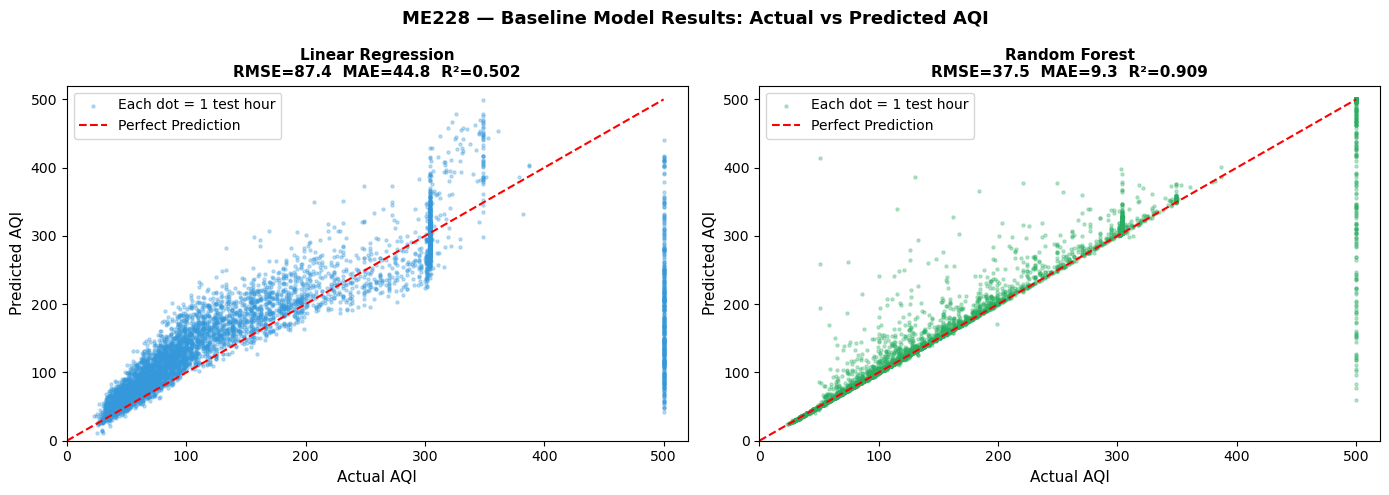


Plot saved as ME228_Baseline_Models.png

══ RESULTS SUMMARY ══
Model                    RMSE      MAE       R²
----------------------------------------------
Linear Regression       87.45    44.79   0.5020
Random Forest           37.47     9.34   0.9086


In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

df = pd.read_csv('ME228_Clean_Dataset.csv')

# ── Feature Selection ──
# Drop non-numeric / target / leakage columns
drop_cols = ['datetime', 'aqi_category', 'pm25_category_india', 
             'dominant_pollutant', 'humidity_category', 'wind_category',
             'time_of_day']
df_model = df.drop(columns=drop_cols)

# Encode categorical columns
le = LabelEncoder()
df_model['season'] = le.fit_transform(df_model['season'])  # monsoon/summer etc → numbers

# Convert booleans to int
bool_cols = ['is_weekend', 'is_raining', 'heavy_rain', 'festival_period', 'crop_burning_season']
for col in bool_cols:
    df_model[col] = df_model[col].astype(int)

# Features and target
X = df_model.drop(columns=['AQI'])
y = df_model['AQI']

print("Features used:", list(X.columns))
print("Total features:", X.shape[1])
print("Total samples:", X.shape[0])

# ── Train/Test Split (80/20) ──
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {len(X_train)} | Test size: {len(X_test)}")

# ── Model 1: Linear Regression ──
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
r2_lr   = r2_score(y_test, y_pred_lr)

print("\n── Linear Regression ──")
print(f"RMSE : {rmse_lr:.2f}")
print(f"MAE  : {mae_lr:.2f}")
print(f"R²   : {r2_lr:.4f}")

# ── Model 2: Random Forest (baseline comparison) ──
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
mae_rf  = mean_absolute_error(y_test, y_pred_rf)
r2_rf   = r2_score(y_test, y_pred_rf)

print("\n── Random Forest ──")
print(f"RMSE : {rmse_rf:.2f}")
print(f"MAE  : {mae_rf:.2f}")
print(f"R²   : {r2_rf:.4f}")

# ── Plot: Actual vs Predicted ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear Regression
axes[0].scatter(y_test, y_pred_lr, alpha=0.3, s=5, color='#3498db', label='Each dot = 1 test hour')
axes[0].plot([0, 500], [0, 500], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[0].set_xlabel('Actual AQI', fontsize=11)
axes[0].set_ylabel('Predicted AQI', fontsize=11)
axes[0].set_title(f'Linear Regression\nRMSE={rmse_lr:.1f}  MAE={mae_lr:.1f}  R²={r2_lr:.3f}',
                  fontsize=11, fontweight='bold')
axes[0].legend(loc='upper left')
axes[0].set_xlim(0, 520)
axes[0].set_ylim(0, 520)

# Random Forest
axes[1].scatter(y_test, y_pred_rf, alpha=0.3, s=5, color='#27ae60', label='Each dot = 1 test hour')
axes[1].plot([0, 500], [0, 500], 'r--', linewidth=1.5, label='Perfect Prediction')
axes[1].set_xlabel('Actual AQI', fontsize=11)
axes[1].set_ylabel('Predicted AQI', fontsize=11)
axes[1].set_title(f'Random Forest\nRMSE={rmse_rf:.1f}  MAE={mae_rf:.1f}  R²={r2_rf:.3f}',
                  fontsize=11, fontweight='bold')
axes[1].legend(loc='upper left')
axes[1].set_xlim(0, 520)
axes[1].set_ylim(0, 520)

plt.suptitle('ME228 — Baseline Model Results: Actual vs Predicted AQI',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('ME228_Baseline_Models.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nPlot saved as ME228_Baseline_Models.png")

# ── Summary Table ──
print("\n══ RESULTS SUMMARY ══")
print(f"{'Model':<20} {'RMSE':>8} {'MAE':>8} {'R²':>8}")
print("-" * 46)
print(f"{'Linear Regression':<20} {rmse_lr:>8.2f} {mae_lr:>8.2f} {r2_lr:>8.4f}")
print(f"{'Random Forest':<20} {rmse_rf:>8.2f} {mae_rf:>8.2f} {r2_rf:>8.4f}")